# Initialization

## Package Imports

In [ ]:
from google.colab import drive

import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
import os
from PIL import Image

## Mount Drive

In [ ]:
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/CSCI-B 556: Applied ML/Homework 3"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CSCI-B 556: Applied ML/Homework 3


## Constants

In [ ]:
SEED = 102800

## Error Handling

In [ ]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Data Set Import

In [ ]:
%ls

car_duck_cnn.pth  image_files/  pokemon_dataset/  q6_files/


In [ ]:
%cd pokemon_dataset

/content/drive/MyDrive/CSCI-B 556: Applied ML/Homework 3/pokemon_dataset


# Part 1
Apply PCA to the images from different conditions (each folder contains images for one of the conditions: realistic, features, blurred, geons, and silhouettes; you need to apply PCA separately for images in each of the folders).  How many components do you need to preserve at least 95% of the variance in each condition? Why do some conditions require more components than others?  [3 points]

First, we get the paths to all the image directories.

In [ ]:
from pathlib import Path

In [ ]:
%ls

images/  pokemon.csv


In [ ]:
pokemon_df = pd.read_csv("pokemon.csv")
pokemon_df.head()

,Name,Type1,Type2,Evolution
0,bulbasaur,Grass,Poison,ivysaur
1,ivysaur,Grass,Poison,venusaur
2,venusaur,Grass,Poison,NaN
3,charmander,Fire,NaN,charmeleon
4,charmeleon,Fire,NaN,charizard


In [ ]:
pokemon_df["Generation"] = None

In [ ]:
for pokemon_id in pokemon_df.index:
  generation = 1
  if pokemon_id > 151:
    generation = 2
  elif pokemon_id > 251:
    generation = 3
  elif pokemon_id > 386:
    generation = 4
  elif pokemon_id > 493:
    generation = 5
  elif pokemon_id > 649:
    generation = 6
  elif pokemon_id > 721:
    generation = 7
  elif pokemon_id > 809:
    generation = 8
  elif pokemon_id > 898:
    generation = 9
  elif pokemon_id > 1025:
    generation = 10

  pokemon_df.at[pokemon_id, "Generation"] = generation

In [ ]:
pokemon_df.head()

,Name,Type1,Type2,Evolution,Generation
0,bulbasaur,Grass,Poison,ivysaur,1
1,ivysaur,Grass,Poison,venusaur,1
2,venusaur,Grass,Poison,NaN,1
3,charmander,Fire,NaN,charmeleon,1
4,charmeleon,Fire,NaN,charizard,1


In [ ]:
pokemon_df["Images"] = None

In [ ]:
pokemon_df

,Name,Type1,Type2,Evolution,Generation,Images
0,bulbasaur,Grass,Poison,ivysaur,1,None
1,ivysaur,Grass,Poison,venusaur,1,None
2,venusaur,Grass,Poison,NaN,1,None
3,charmander,Fire,NaN,charmeleon,1,None
4,charmeleon,Fire,NaN,charizard,1,None
...,...,...,...,...,...,...
804,stakataka,Rock,Steel,NaN,2,None
805,blacephalon,Fire,Ghost,NaN,2,None
806,zeraora,Electric,NaN,NaN,2,None
807,meltan,Steel,NaN,NaN,2,None


Claude helped me with file importing relating to naming

In [ ]:
import os
from PIL import Image
import numpy as np

def import_images(directory, dimensions, column_name="Images"):
  for filename in os.listdir(directory):
    pokemon_name = os.path.splitext(filename)[0]

    img = Image.open(os.path.join(directory, filename))
    img = img.convert('RGB')
    img = img.resize(dimensions)
    img = np.array(img)

    mask = pokemon_df["Name"].str.lower() == pokemon_name.lower()
    if mask.any():
      idx = pokemon_df[mask].index[0]
      pokemon_df.at[idx, column_name] = img
    else:
      print(f"Warning: No match found for {pokemon_name}")

In [ ]:
import_images("images", (128, 128))

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
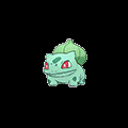

In [ ]:
pokemon_df.at[0, "Images"]

In [ ]:
model_info = {}

In [ ]:
def get_pca(n_components=0.95, update_dict=False):
  images = pokemon_df["Images"].to_numpy().flatten()
  images = np.stack(images).reshape(len(images), -1)

  pca = PCA(n_components=n_components)
  pca.fit(images)
  print(f"Number of components: {pca.n_components_}")

  if update_dict:
    model_info["PCA Function"] = pca
  return pca

In [ ]:
pca = get_pca(update_dict=True)

Number of components: 436


# Part 2
Plot 10 realistic images of your choice in the original form (without PCA) and then plot their reconstruction (projection in the original space) after you kept at least 95% of the variance using PCA. [3 points]

In [ ]:
pokemon_names = ["bulbasaur",
               "pichu",
               "pikachu",
               "infernape",
               "piplup",
               "weedle",
               "zubat",
               "mew",
               "dugtrio",
               "houndoom"]

In [ ]:
def apply_pca(pokemon_names, pca_model):
  output_images = []
  for pokemon in pokemon_names:
    mask = pokemon_df["Name"].str.lower() == pokemon

    if not mask.any():
      print(f"Warning: Pokemon '{pokemon}' not found in DataFrame")
      continue

    img = pokemon_df.loc[mask, "Images"].iloc[0]
    img = img.reshape(1,-1)

    img_pca = pca_model.transform(img)
    img_reconstructed = pca_model.inverse_transform(img_pca)

    output_img = img_reconstructed.reshape(128, 128, 3)
    output_img = np.clip(output_img, 0, 255).astype(np.uint8)

    output_images.append(output_img)
  return np.array(output_images)

In [ ]:
# necessary because of errors in side_by_side

def get_images(pokemon_names):
  output_images = []

  for pokemon in pokemon_names:
    mask = pokemon_df["Name"].str.lower() == pokemon
    if mask.any():
      img = pokemon_df.loc[mask, "Images"].iloc[0]
      output_images.append(img)
    else:
      print(f"Warning: Pokemon '{pokemon}' not found in DataFrame")

  return np.array(output_images)


In [ ]:
og_images = get_images(pokemon_names)
pca_images = apply_pca(pokemon_names, pca)

In [ ]:
img_pairs =list(zip(og_images, pca_images))

In [ ]:
def side_by_side(img_pairs):
  for og, pca in img_pairs:
    ig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    ax1.imshow(og)
    ax1.set_title("Original")
    ax1.axis('off')

    ax2.imshow(pca)
    ax2.set_title("PCA")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# np.save("pca_images.npy", pca_images)

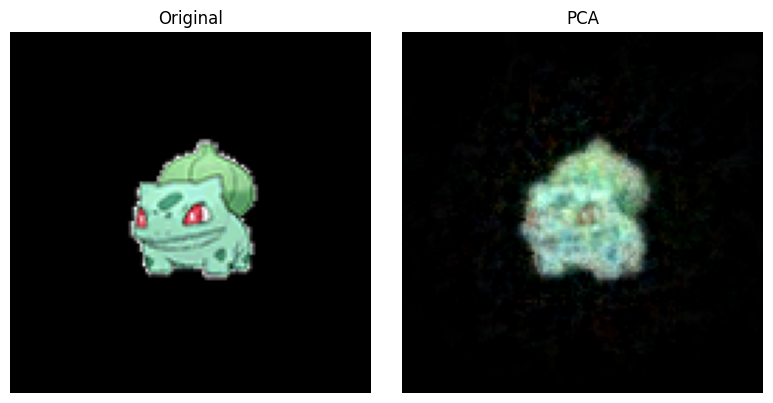

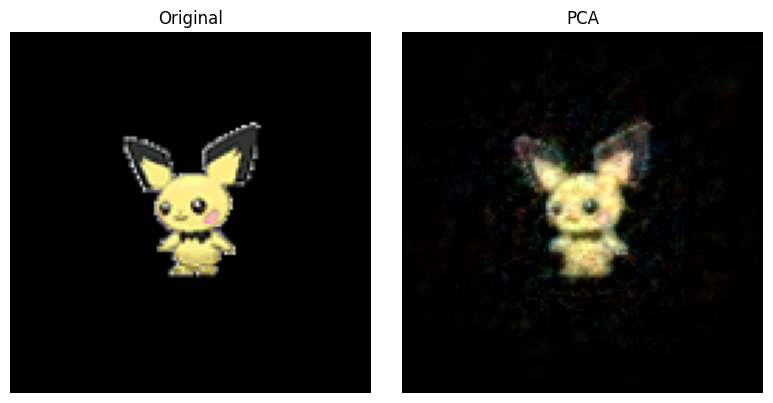

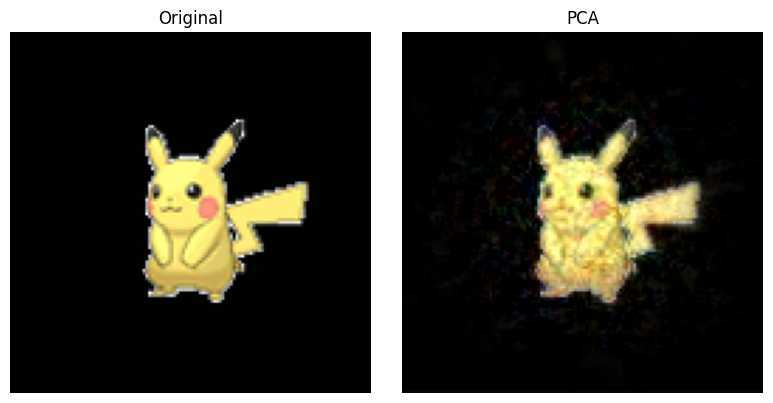

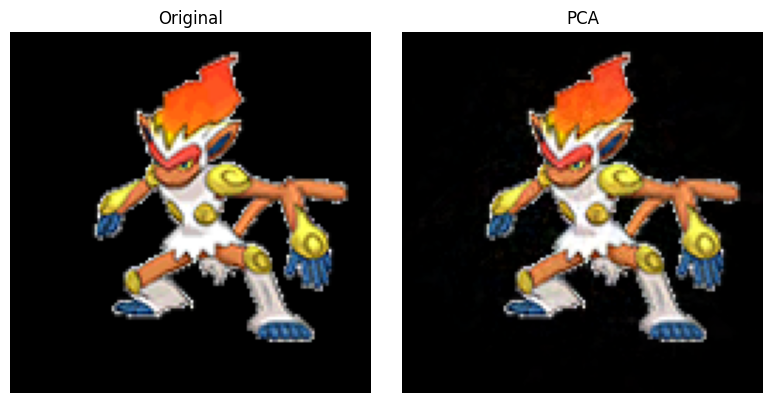

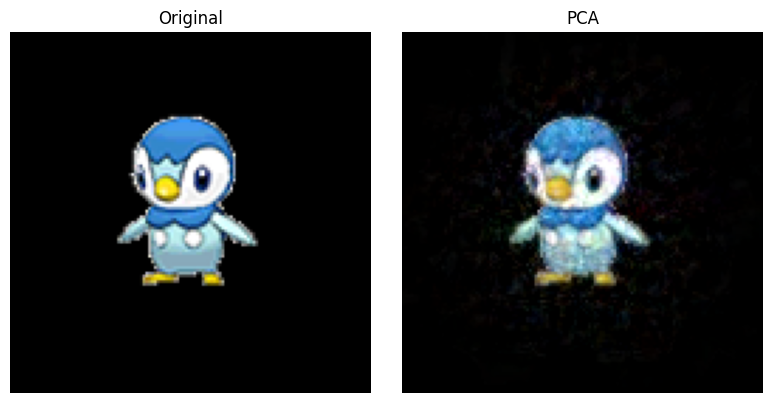

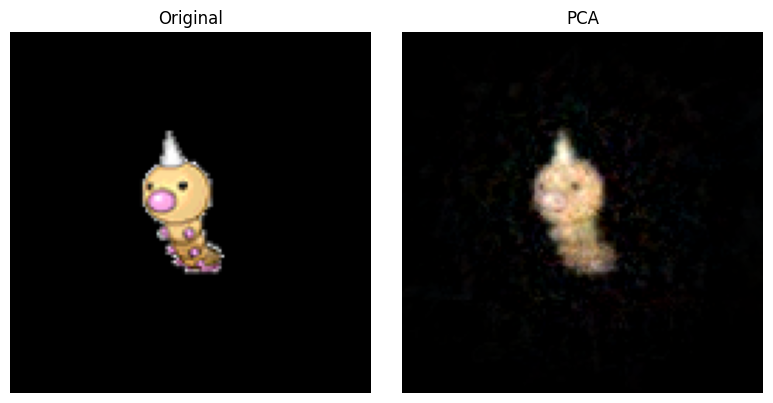

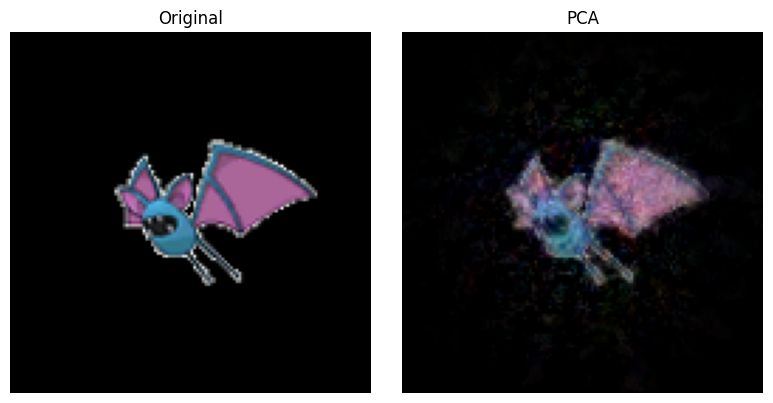

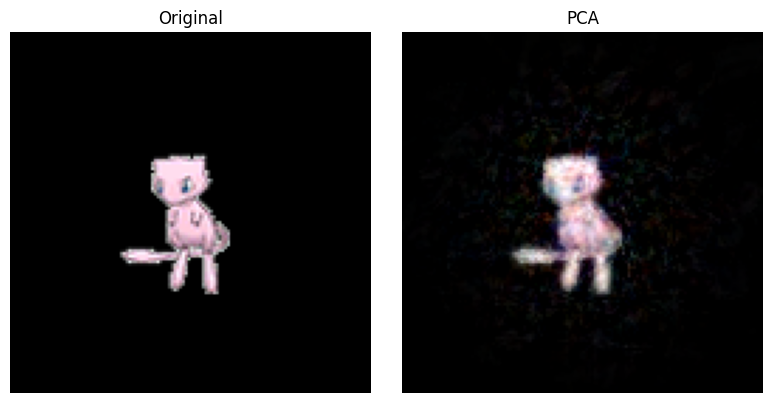

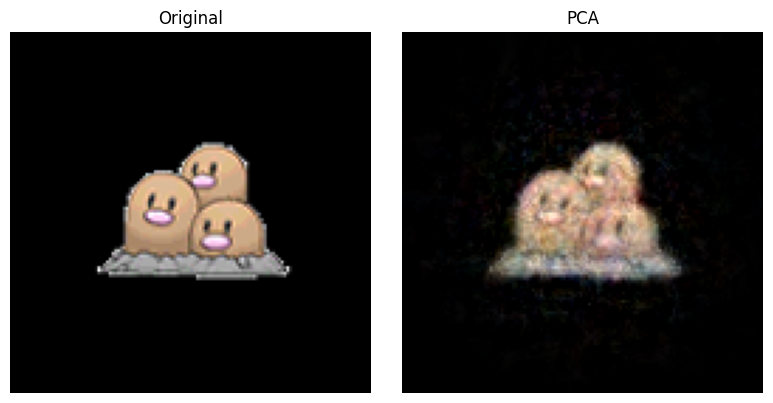

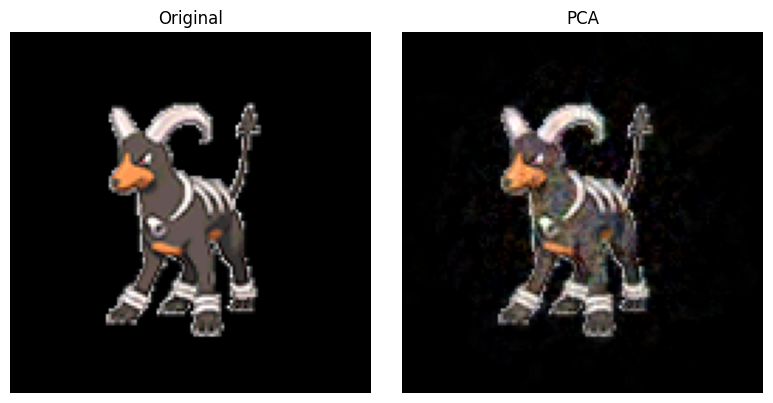

In [ ]:
side_by_side(img_pairs)

# Part 3
Each of the images belongs to one of eight clusters (Airplane, Car, Chair, Cup, Dog, Donkey, Duck, Hat). The clusters is indicated by the image name. We will now try to see if the visualization can help us identify different clusters.


## 3A
For each condition (folder) use PCA to reduce dimensionality to only 2 dimensions. How much of the variance is explained with the first two principal components for each condition? [3 points].

In [ ]:
pca_2D = get_pca(n_components=2)

Number of components: 2


In [ ]:
print(f"Explained variance: {sum(pca_2D.explained_variance_ratio_)*100:,.2f}%")

Explained variance: 19.45%


## 3B
Plot a 2D scatter plot of the images spanned by the first two principal components. Each image will be represented with a dot. Make the color of the dot correspond to the image class (so you will have eight different colors). Repeat the process and create the same type of plots for t-SNE, LLE and UMAP. [6 points]

(A modified version of) Claude's option that was not a bunch of if statements.

In [ ]:
pokemon_df.columns

Index(['Name', 'Type1', 'Type2', 'Evolution', 'Generation', 'Images'], dtype='object')

Scatterplot courtesy of Claude

In [ ]:
from sklearn.manifold import LocallyLinearEmbedding as LLE
from sklearn.manifold import TSNE
from umap import UMAP

In [ ]:
def load_images(column_name="Images"):
  images = pokemon_df[column_name].to_numpy()
  images = np.stack([img.flatten() for img in images])

  return images

In [ ]:
def plot_scatter(model):
    """
    Plot 2D scatter of images using first 2 PCA components.
    """
    # Fit model
    model_instance = model(n_components=2)

    # Convert images to 2D array
    images = load_images()

    images_set = model_instance.fit_transform(images)

    labels = pokemon_df["Type1"].values  # Use .values to get numpy array
    class_names = pokemon_df["Type1"].unique()

    print(f"Transformed shape: {images_set.shape}")
    print(f"Labels shape: {labels.shape}")
    print(f"Class names: {class_names}")
    print(f"Sample labels: {labels[:5]}")

    # Create scatter plot
    plt.figure(figsize=(10, 8))

    # Use different color for each class
    num_classes = len(class_names)
    colors = plt.cm.tab10(np.linspace(0, 1, num_classes))

    for class_idx, class_name in enumerate(class_names):
        mask = labels == class_name
        print(f"{class_name}: {mask.sum()} points")  # Debug: how many points?

        if mask.sum() > 0:  # Only plot if there are points
            plt.scatter(images_set[mask, 0],
                       images_set[mask, 1],
                       c=[colors[class_idx]],
                       label=class_name,
                       alpha=0.7,
                       s=50)

    plt.xlabel(f'First Principal Component')
    plt.ylabel(f'Second Principal Component')
    plt.title(f'Images in {model_instance.__class__.__name__} Space (First 2 Components)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
models = [PCA, LLE, TSNE, UMAP]

Transformed shape: (809, 2)
Labels shape: (809,)
Class names: ['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']
Sample labels: ['Grass' 'Grass' 'Grass' 'Fire' 'Fire']
Grass: 78 points
Fire: 53 points
Water: 114 points
Bug: 72 points
Normal: 105 points
Poison: 34 points
Electric: 40 points
Ground: 32 points
Fairy: 18 points
Fighting: 29 points
Psychic: 53 points
Rock: 46 points
Ghost: 27 points
Ice: 23 points
Dragon: 27 points
Dark: 29 points
Steel: 26 points
Flying: 3 points


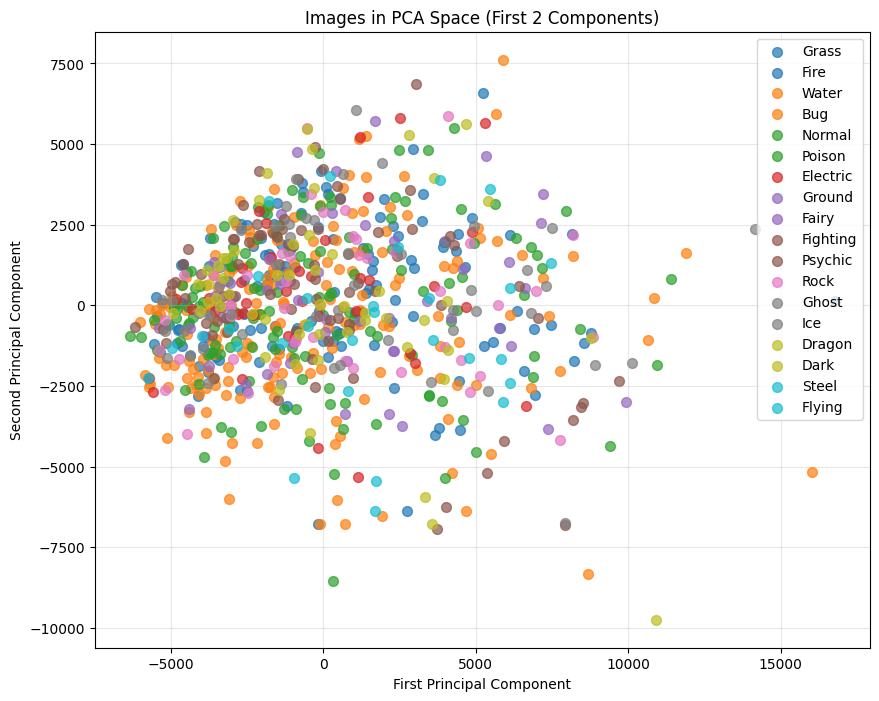

Transformed shape: (809, 2)
Labels shape: (809,)
Class names: ['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']
Sample labels: ['Grass' 'Grass' 'Grass' 'Fire' 'Fire']
Grass: 78 points
Fire: 53 points
Water: 114 points
Bug: 72 points
Normal: 105 points
Poison: 34 points
Electric: 40 points
Ground: 32 points
Fairy: 18 points
Fighting: 29 points
Psychic: 53 points
Rock: 46 points
Ghost: 27 points
Ice: 23 points
Dragon: 27 points
Dark: 29 points
Steel: 26 points
Flying: 3 points


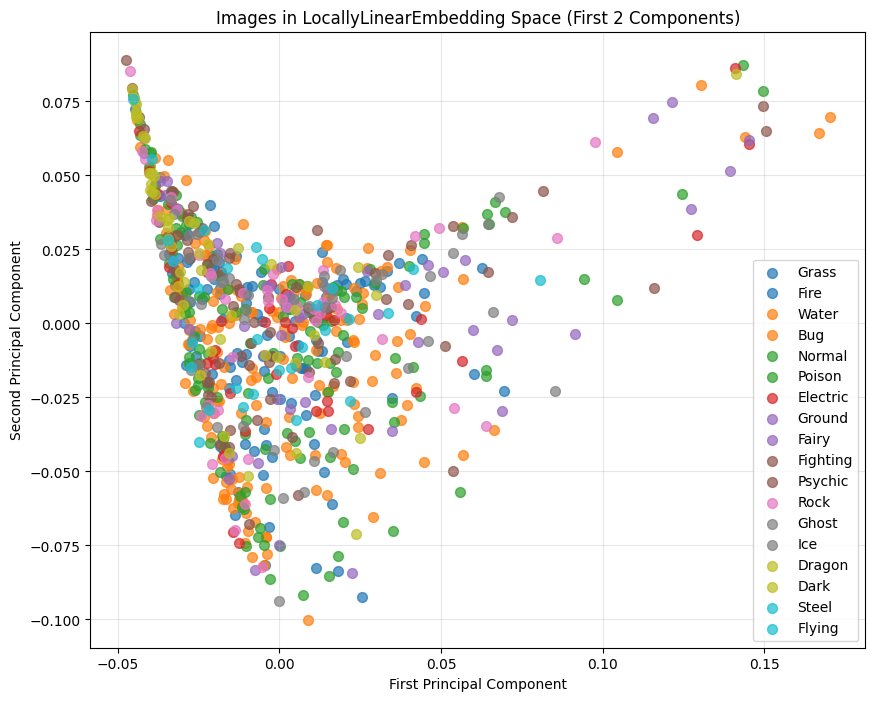

Transformed shape: (809, 2)
Labels shape: (809,)
Class names: ['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']
Sample labels: ['Grass' 'Grass' 'Grass' 'Fire' 'Fire']
Grass: 78 points
Fire: 53 points
Water: 114 points
Bug: 72 points
Normal: 105 points
Poison: 34 points
Electric: 40 points
Ground: 32 points
Fairy: 18 points
Fighting: 29 points
Psychic: 53 points
Rock: 46 points
Ghost: 27 points
Ice: 23 points
Dragon: 27 points
Dark: 29 points
Steel: 26 points
Flying: 3 points


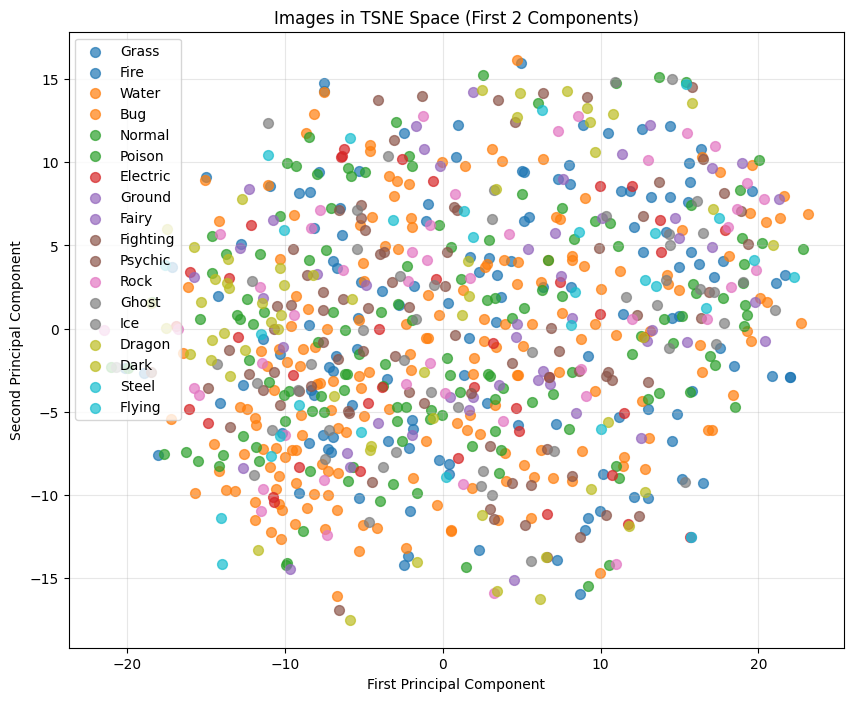

Transformed shape: (809, 2)
Labels shape: (809,)
Class names: ['Grass' 'Fire' 'Water' 'Bug' 'Normal' 'Poison' 'Electric' 'Ground'
 'Fairy' 'Fighting' 'Psychic' 'Rock' 'Ghost' 'Ice' 'Dragon' 'Dark' 'Steel'
 'Flying']
Sample labels: ['Grass' 'Grass' 'Grass' 'Fire' 'Fire']
Grass: 78 points
Fire: 53 points
Water: 114 points
Bug: 72 points
Normal: 105 points
Poison: 34 points
Electric: 40 points
Ground: 32 points
Fairy: 18 points
Fighting: 29 points
Psychic: 53 points
Rock: 46 points
Ghost: 27 points
Ice: 23 points
Dragon: 27 points
Dark: 29 points
Steel: 26 points
Flying: 3 points


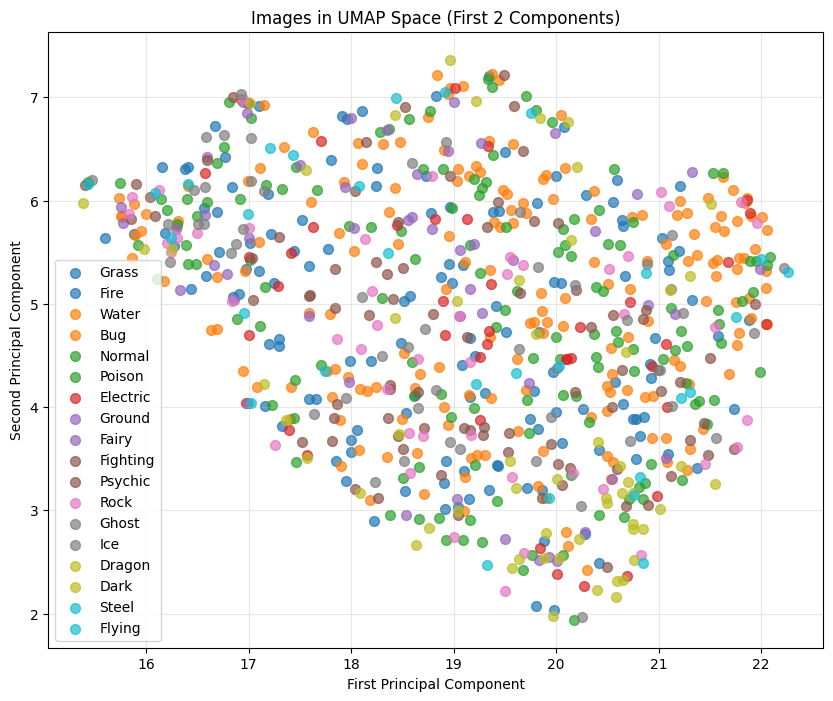

In [ ]:
for model in models:
  plot_scatter(model)

# Part 4
Cluster the images in each condition using K-Means (apply K-means separately to images from each folder).

## 4A
To make the process faster, reduce the dimensionality using PCA, but keep at least 95% of the variance. Determine the number of clusters using one of the techniques we discussed in class, suitable for the K-means algorithm. [2 points]

In [ ]:
unique_types = len(pokemon_df["Type1"].unique())

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

def get_best_k(max_k = unique_types):
  """
  Arguments:
    max_k: the maximum number of clusters to try, 16 defaulted since 8 known clusters
  Returns:
    the number of clusters that maximizes silhouette score
  """
  scores = []

  images = load_images()
  images_pca = pca.transform(images)

  for k in range(2, max_k+1):
    kmeans = KMeans(n_clusters=k, random_state=SEED)
    labels = kmeans.fit_predict(images_pca)
    score = silhouette_score(images_pca, labels)
    scores.append(score)

  return np.argmax(scores) + 2



In [ ]:
print(f"Best k based on silhouette score: {get_best_k()}")

Best k based on silhouette score: 2


## 4B
Set the number of clusters to 8 (ground truth), report clustering accuracy (choose an appropriate mapping) and show a confusion matrix. [3 points]

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

# Claude implementation of Hungarian Algorithm
def find_best_mapping(true_labels, cluster_labels, n_clusters=unique_types):
    """
    Find the best mapping between cluster labels and true labels.
    Uses the Hungarian algorithm for optimal assignment.

    Parameters:
    -----------
    true_labels : np.array
        Ground truth labels
    cluster_labels : np.array
        Predicted cluster labels
    n_clusters : int
        Number of clusters

    Returns:
    --------
    mapping : dict
        Dictionary mapping cluster_id -> true_label
    """
    # Create confusion matrix (clusters vs true labels)
    cm = confusion_matrix(true_labels, cluster_labels)

    # Use Hungarian algorithm to find best mapping
    # We want to maximize matches, so negate the matrix
    row_ind, col_ind = linear_sum_assignment(-cm)

    # Create mapping dictionary
    mapping = {cluster_id: true_label for cluster_id, true_label in zip(col_ind, row_ind)}

    return mapping

def apply_mapping(cluster_labels, mapping):
    """Apply mapping to convert cluster labels to predicted true labels."""
    return np.array([mapping[label] for label in cluster_labels])

In [ ]:
def load_images_pca():
  images = pokemon_df["Images"].to_numpy()
  images = np.stack([img.flatten() for img in images])

  images_pca = pca.transform(images)

  return np.array(images_pca)

In [ ]:
from sklearn.preprocessing import LabelEncoder

def test_kmeans():
  images = load_images()
  images_pca = load_images_pca()

  # Encode true_labels from strings to integers
  label_encoder = LabelEncoder()
  true_labels_encoded = label_encoder.fit_transform(pokemon_df["Type1"])
  true_labels_names = label_encoder.classes_ # Store original names for plotting

  kmeans = KMeans(n_clusters=8, random_state=SEED)
  predicted_clusters = kmeans.fit_predict(images_pca)

  # Use the encoded true labels for mapping
  mapping = find_best_mapping(true_labels_encoded, predicted_clusters, n_clusters=len(true_labels_names))

  predicted_labels = apply_mapping(predicted_clusters, mapping)

  #---#
  # Calculate accuracy using encoded labels
  accuracy = accuracy_score(true_labels_encoded, predicted_labels)
  print(f"\nClustering Accuracy: {accuracy:.2%}")

  # Create confusion matrix with encoded labels
  cm = confusion_matrix(true_labels_encoded, predicted_labels)

  # Use original type names for heatmap labels
  categories = true_labels_names

  # Plot confusion matrix
  plt.figure(figsize=(12, 10)) # Increased figure size for better readability with more categories
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=categories,
              yticklabels=categories,
              cbar_kws={'label': 'Count'})
  plt.xlabel('Predicted Label', fontsize=12)
  plt.ylabel('True Label', fontsize=12)
  plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.2%}',
            fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()


Clustering Accuracy: 13.84%


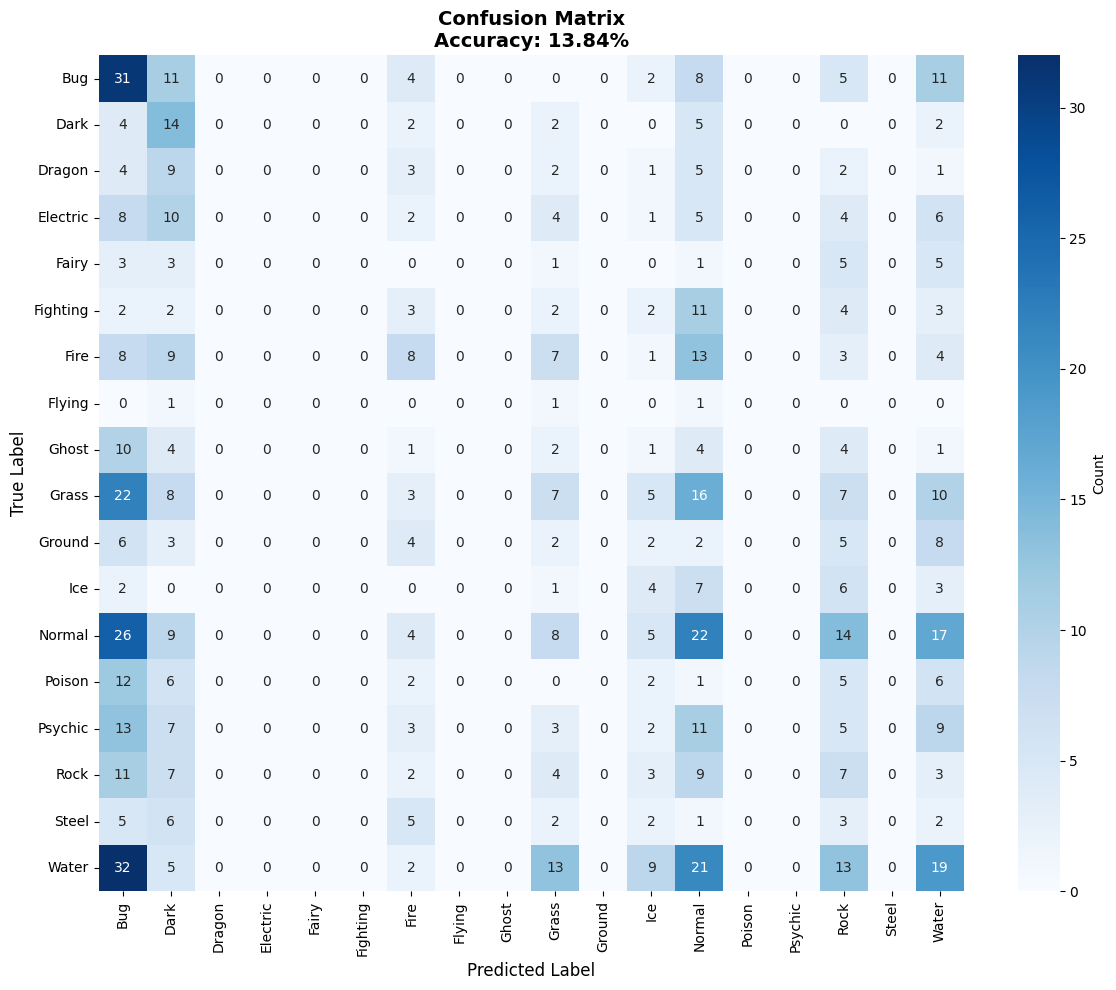

In [ ]:
test_kmeans()

## 4C
Repeat step B, but instead of features derived using PCA, use features obtained with a pretrained ResNet model - use penultimate layer (size of the ResNet model and data used for pretraining are up to you; note that you will need to resize images to 224×224 for ResNet). [3 points]

In [ ]:
# If statement courtesy of Gemini
if 'Images_224' not in pokemon_df.columns:
    pokemon_df['Images_224'] = None

import_images("images", (224, 224), column_name="Images_224")

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image

# Load pretrained ResNet (you can choose resnet18, resnet34, resnet50, etc.)
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remove the final classification layer to get penultimate layer features
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()  # Set to evaluation mode

# Define image preprocessing for ResNet (requires 224x224)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

def extract_resnet_features_from_df(column_name="Images_224", batch_size=16):
    """
    Extract ResNet features directly from DataFrame without loading all images first.

    Parameters:
    -----------
    column_name : str
        Name of column containing images
    batch_size : int
        Number of images to process at once (reduced for memory)

    Returns:
    --------
    features : np.array
        Feature vectors
    """
    features = []
    n_images = len(pokemon_df)

    with torch.no_grad():
        for i in range(0, n_images, batch_size):
            batch_tensors = []

            # Process one batch
            for j in range(i, min(i + batch_size, n_images)):
                img = pokemon_df.iloc[j][column_name]

                # Convert numpy array to PIL Image
                if isinstance(img, np.ndarray):
                    img = Image.fromarray(img.astype('uint8'))

                # Preprocess and add to batch
                img_tensor = preprocess(img)
                batch_tensors.append(img_tensor)

            # Stack into batch and process
            batch = torch.stack(batch_tensors)
            batch_features = resnet(batch)
            batch_features = batch_features.squeeze().cpu().numpy()

            # Handle single image case
            if batch_features.ndim == 1:
                batch_features = batch_features.reshape(1, -1)

            features.append(batch_features)

            # Progress update
            if (i // batch_size) % 10 == 0:
                print(f"  Processed {min(i + batch_size, n_images)}/{n_images} images...")

            # Clear cache
            del batch, batch_tensors, batch_features
            torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return np.vstack(features)

In [ ]:
def test_kmeans_resnet(n_clusters=18):
    """
    Test K-means clustering using ResNet features.

    Parameters:
    -----------
    n_clusters : int
        Number of clusters (set to 18 for ground truth)
    """
    # Get ResNet features
    resnet_feats = extract_resnet_features_from_df("Images_224", batch_size=16)

    true_labels = pokemon_df["Type1"]

    # Encode string labels to numbers
    label_encoder = LabelEncoder()
    true_labels_encoded = label_encoder.fit_transform(true_labels)

    # Run K-means
    print(f"Running K-means with {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    predicted_clusters = kmeans.fit_predict(resnet_feats)

    # Find best mapping using Hungarian algorithm
    mapping = find_best_mapping(true_labels_encoded, predicted_clusters, n_clusters=n_clusters)

    # Apply mapping
    predicted_labels = apply_mapping(predicted_clusters, mapping)

    # Calculate accuracy
    accuracy = accuracy_score(true_labels_encoded, predicted_labels)
    print(f"\nClustering Accuracy: {accuracy:.2%}")

    # Create confusion matrix
    cm = confusion_matrix(true_labels_encoded, predicted_labels)

    # Get category names in the right order
    categories = label_encoder.classes_

    # Plot confusion matrix
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories,
                yticklabels=categories,
                cbar_kws={'label': 'Count'})
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title(f'Confusion Matrix (ResNet Features, K={n_clusters})\nAccuracy: {accuracy:.2%}',
                fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return accuracy, cm, mapping, predicted_labels

  Processed 16/809 images...
  Processed 176/809 images...
  Processed 336/809 images...
  Processed 496/809 images...
  Processed 656/809 images...
  Processed 809/809 images...
Running K-means with 18 clusters...

Clustering Accuracy: 15.45%


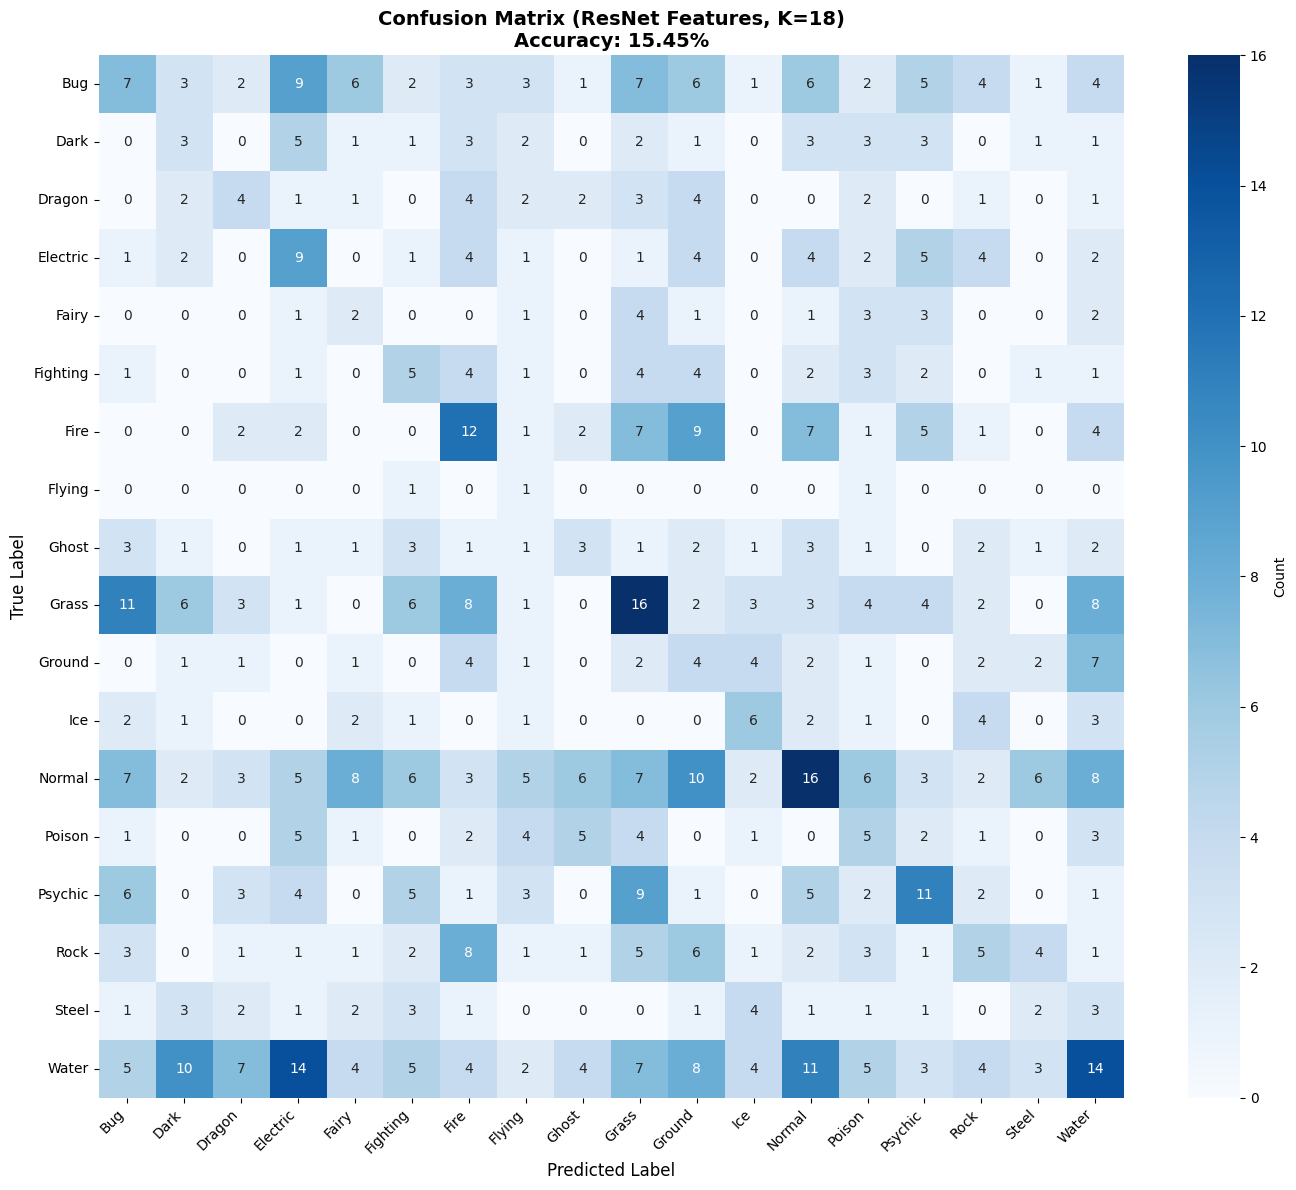

In [ ]:
# Run the test
accuracy, cm, mapping, predicted_labels = test_kmeans_resnet(n_clusters=18)

# Part 5
Cluster the in each condition using EM.

## 5A
Reduce again the dimensionality using PCA, but keep at least 95% of the variance. Determine the number of clusters using one of the techniques we discussed in class, suitable for the EM algorithm. [2 points]

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

def apply_pca(n_components=0.95):
    """
    Apply PCA to ResNet features, keeping 95% of variance.

    Parameters:
    -----------
    resnet_features : np.array
        ResNet features from penultimate layer
    n_components : float
        Fraction of variance to retain (0.95 = 95%)

    Returns:
    --------
    pca_features : np.array
        PCA-transformed features
    pca : PCA object
        Fitted PCA model
    """
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(load_images())

    return pca_features, pca

def find_optimal_clusters_bic(features, max_clusters=30, random_state=SEED):
    """
    Find optimal number of clusters using BIC (Bayesian Information Criterion).
    Lower BIC indicates better model fit with appropriate penalty for complexity.

    Parameters:
    -----------
    features : np.array
        Feature vectors
    max_clusters : int
        Maximum number of clusters to test
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    optimal_k : int
        Optimal number of clusters
    bic_scores : list
        BIC scores for each k
    """
    bic_scores = []
    k_range = range(2, max_clusters + 1)

    print("Computing BIC scores...")
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=random_state, n_init=10)
        gmm.fit(features)
        bic = gmm.bic(features)
        bic_scores.append(bic)

        if k % 5 == 0:
            print(f"  k={k}: BIC={bic:.2f}")

    # Find k with minimum BIC
    optimal_k = k_range[np.argmin(bic_scores)]

    # Plot BIC scores
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, bic_scores, 'bo-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k, color='r', linestyle='--',
                label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('BIC Score', fontsize=12)
    plt.title('BIC Score vs Number of Clusters (Lower is Better)',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal number of clusters: {optimal_k}")

    return optimal_k, bic_scores

def find_optimal_clusters_aic(features, max_clusters=30, random_state=SEED):
    """
    Find optimal number of clusters using AIC (Akaike Information Criterion).
    Alternative to BIC, generally less conservative (may select more clusters).
    """
    aic_scores = []
    k_range = range(2, max_clusters + 1)

    print("Computing AIC scores...")
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=random_state, n_init=10)
        gmm.fit(features)
        aic = gmm.aic(features)
        aic_scores.append(aic)

        if k % 5 == 0:
            print(f"  k={k}: AIC={aic:.2f}")

    optimal_k = k_range[np.argmin(aic_scores)]

    # Plot AIC scores
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, aic_scores, 'go-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k, color='r', linestyle='--',
                label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('AIC Score', fontsize=12)
    plt.title('AIC Score vs Number of Clusters (Lower is Better)',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal number of clusters: {optimal_k}")

    return optimal_k, aic_scores

Computing BIC scores...
  k=5: BIC=2735080.90
  k=10: BIC=4292812.52
  k=15: BIC=6936957.25
  k=20: BIC=9900319.77
  k=25: BIC=12925722.58
  k=30: BIC=15910242.28


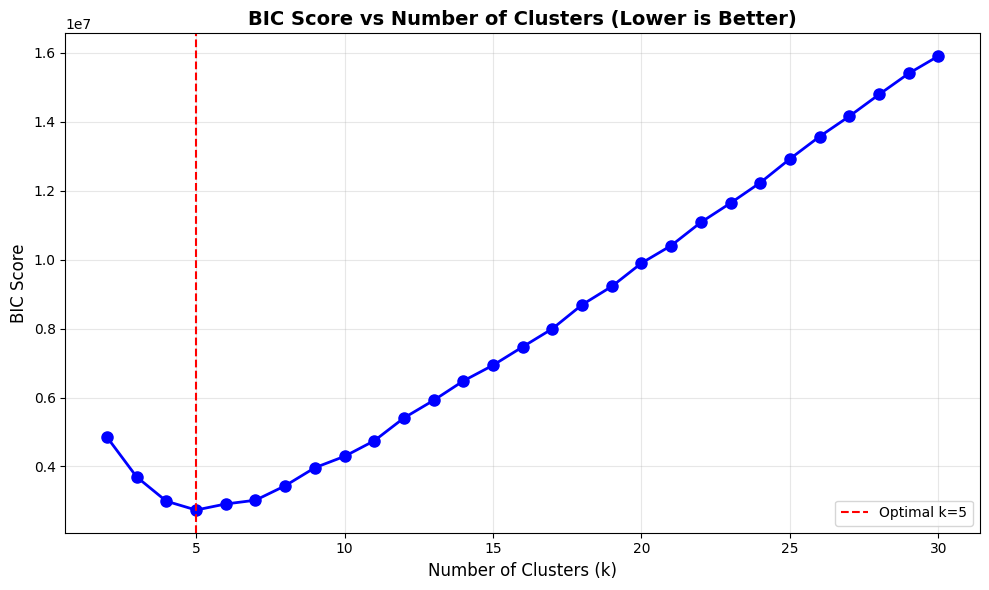


Optimal number of clusters: 5
Computing AIC scores...
  k=5: AIC=488075.38
  k=10: AIC=-201203.23
  k=15: AIC=195931.29
  k=20: AIC=912283.59
  k=25: AIC=1690676.19
  k=30: AIC=2428185.66


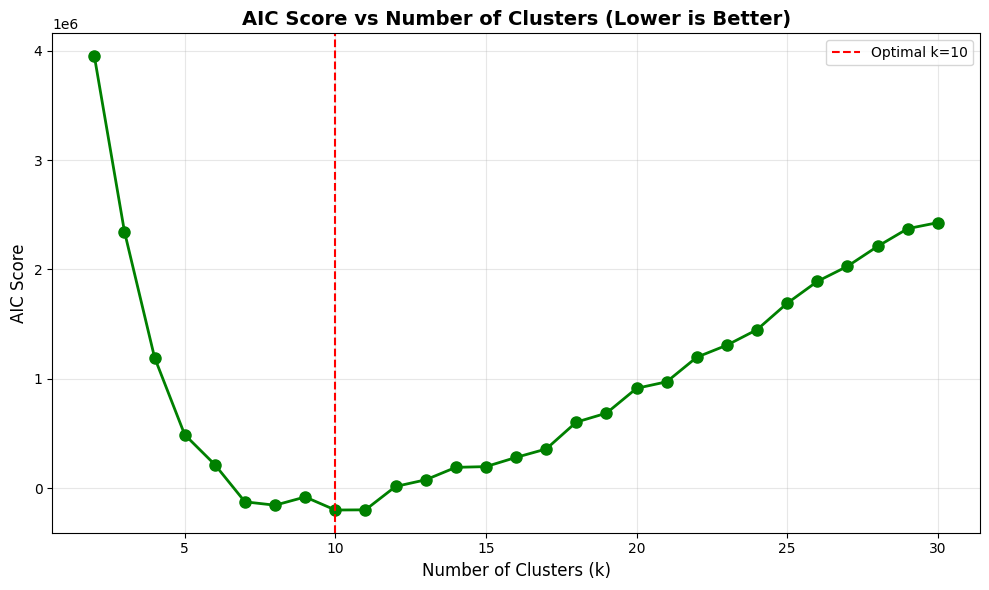


Optimal number of clusters: 10


In [ ]:
# Apply PCA keeping 95% variance
pca_features, pca_model = apply_pca(n_components=0.95)

# Find optimal number of clusters using BIC
optimal_k_bic, bic_scores = find_optimal_clusters_bic(pca_features, max_clusters=30)

# Alternative: Use AIC instead
optimal_k_aic, aic_scores = find_optimal_clusters_aic(pca_features, max_clusters=30)

## 5B
Set the number of clusters to 8 (ground truth), report clustering accuracy (choose an appropriate mapping) and show a confusion matrix. [3 points]

In [ ]:
def test_gmm(n_components=unique_types, features=pca_features):
  images = load_images()
  # images_pca = load_images_pca()

  # Encode true_labels from strings to integers
  label_encoder = LabelEncoder()
  true_labels_encoded = label_encoder.fit_transform(pokemon_df["Type1"])
  true_labels_names = label_encoder.classes_ # Store original names for plotting

  gmm = GaussianMixture(n_components=n_components, random_state=SEED, n_init=10)
  predicted_clusters = gmm.fit_predict(pca_features) # NOTE

  # Use the encoded true labels for mapping
  mapping = find_best_mapping(true_labels_encoded, predicted_clusters, n_clusters=len(true_labels_names))

  predicted_labels = apply_mapping(predicted_clusters, mapping)

  #---#
  # Calculate accuracy using encoded labels
  accuracy = accuracy_score(true_labels_encoded, predicted_labels)
  print(f"\nClustering Accuracy: {accuracy:.2%}")

  # Create confusion matrix with encoded labels
  cm = confusion_matrix(true_labels_encoded, predicted_labels)

  # Use original type names for heatmap labels
  categories = true_labels_names

  # Plot confusion matrix
  plt.figure(figsize=(12, 10)) # Increased figure size for better readability with more categories
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=categories,
              yticklabels=categories,
              cbar_kws={'label': 'Count'})
  plt.xlabel('Predicted Label', fontsize=12)
  plt.ylabel('True Label', fontsize=12)
  plt.title(f'Confusion Matrix\nAccuracy: {accuracy:.2%}',
            fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()


Clustering Accuracy: 13.97%


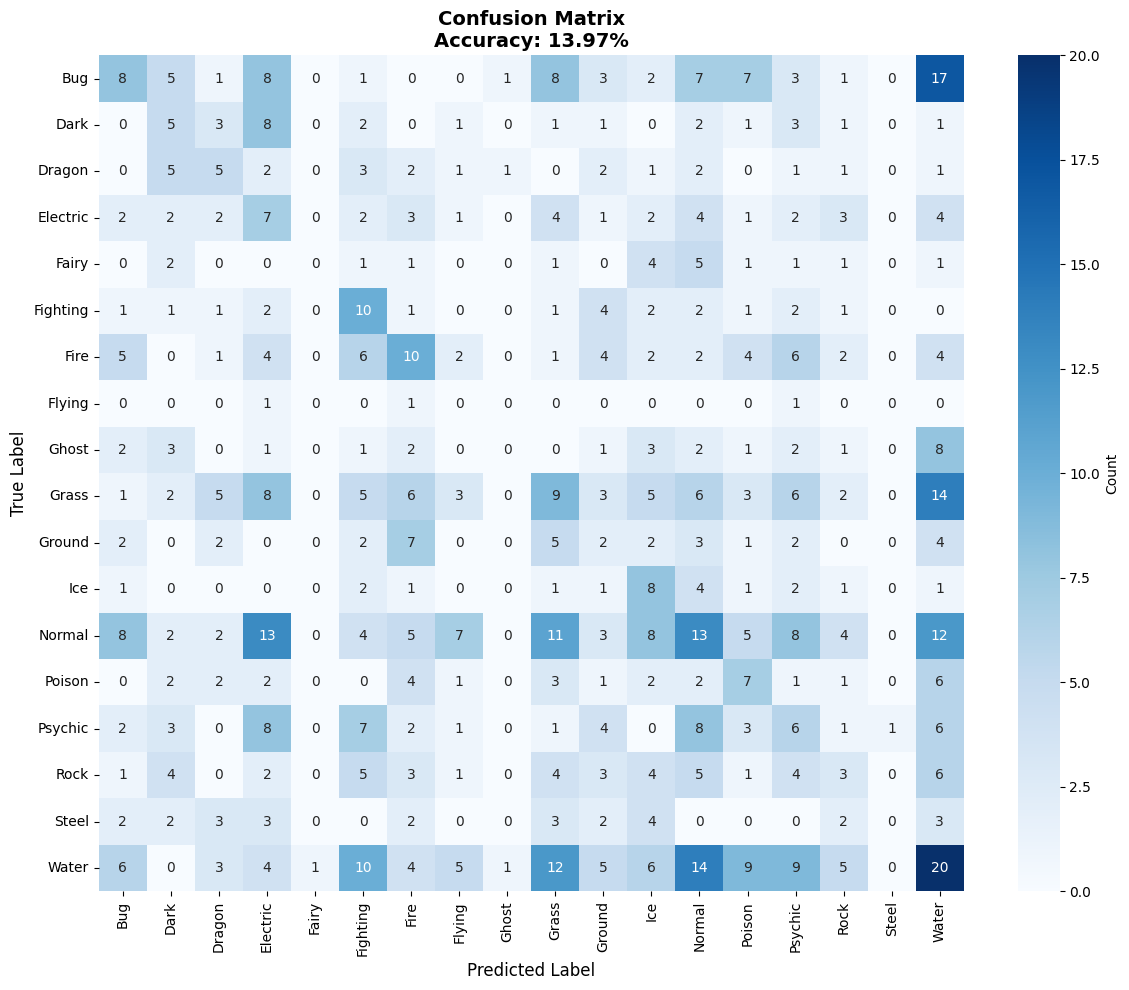

In [ ]:
test_gmm(unique_types)

## 5C
Use the model to generate 5 new images for each condition (using the sample() method), and visualize them in the original image space (since you used PCA, you will need to use its inverse_transform() method).  [4 points]

In [ ]:
def generate_and_visualize_samples(gmm, pca_model, n_samples_per_cluster=5, image_size=(128, 128)):
    """
    Generate new samples from each cluster and visualize in original image space.

    Parameters:
    -----------
    gmm : GaussianMixture
        Fitted Gaussian Mixture Model
    pca_model : PCA
        Fitted PCA model for inverse transform
    n_samples_per_cluster : int
        Number of samples to generate per cluster
    image_size : tuple
        Original image dimensions (height, width)

    Returns:
    --------
    generated_images : np.array
        Array of generated images
    """
    n_clusters = gmm.n_components
    all_generated_images = []

    # Generate samples for each cluster
    for cluster_id in range(n_clusters):
        print(f"Generating {n_samples_per_cluster} samples for cluster {cluster_id}...")

        # Get mean and covariance for this specific cluster
        mean = gmm.means_[cluster_id]
        covariance = gmm.covariances_[cluster_id]

        # Generate samples from this specific Gaussian component
        samples_pca = np.random.multivariate_normal(mean, covariance, n_samples_per_cluster)

        # Transform back to original image space using PCA inverse
        samples_original = pca_model.inverse_transform(samples_pca)

        # Reshape to image dimensions and clip to valid range
        for i in range(n_samples_per_cluster):
            img = samples_original[i].reshape(image_size[0], image_size[1], 3)
            img = np.clip(img, 0, 255).astype(np.uint8)
            all_generated_images.append((cluster_id, img))

    # Visualize all generated images
    cols = n_samples_per_cluster
    rows = n_clusters

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))

    for idx, (cluster_id, img) in enumerate(all_generated_images):
        row = idx // cols
        col = idx % cols

        if rows == 1:
            ax = axes[col]
        elif cols == 1:
            ax = axes[row]
        else:
            ax = axes[row, col]

        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(f'Cluster {cluster_id}', fontsize=10, fontweight='bold', rotation=0, labelpad=40)

    plt.suptitle(f'Generated Samples ({n_samples_per_cluster} per cluster)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return np.array([img for _, img in all_generated_images])

Applying PCA...
Original dimensions: 49152
Reduced dimensions: 436
Explained variance: 0.9501

Fitting Gaussian Mixture Model with k=18...
Generating 5 samples for cluster 0...
Generating 5 samples for cluster 1...
Generating 5 samples for cluster 2...
Generating 5 samples for cluster 3...
Generating 5 samples for cluster 4...
Generating 5 samples for cluster 5...
Generating 5 samples for cluster 6...
Generating 5 samples for cluster 7...
Generating 5 samples for cluster 8...
Generating 5 samples for cluster 9...
Generating 5 samples for cluster 10...
Generating 5 samples for cluster 11...
Generating 5 samples for cluster 12...
Generating 5 samples for cluster 13...
Generating 5 samples for cluster 14...
Generating 5 samples for cluster 15...
Generating 5 samples for cluster 16...
Generating 5 samples for cluster 17...


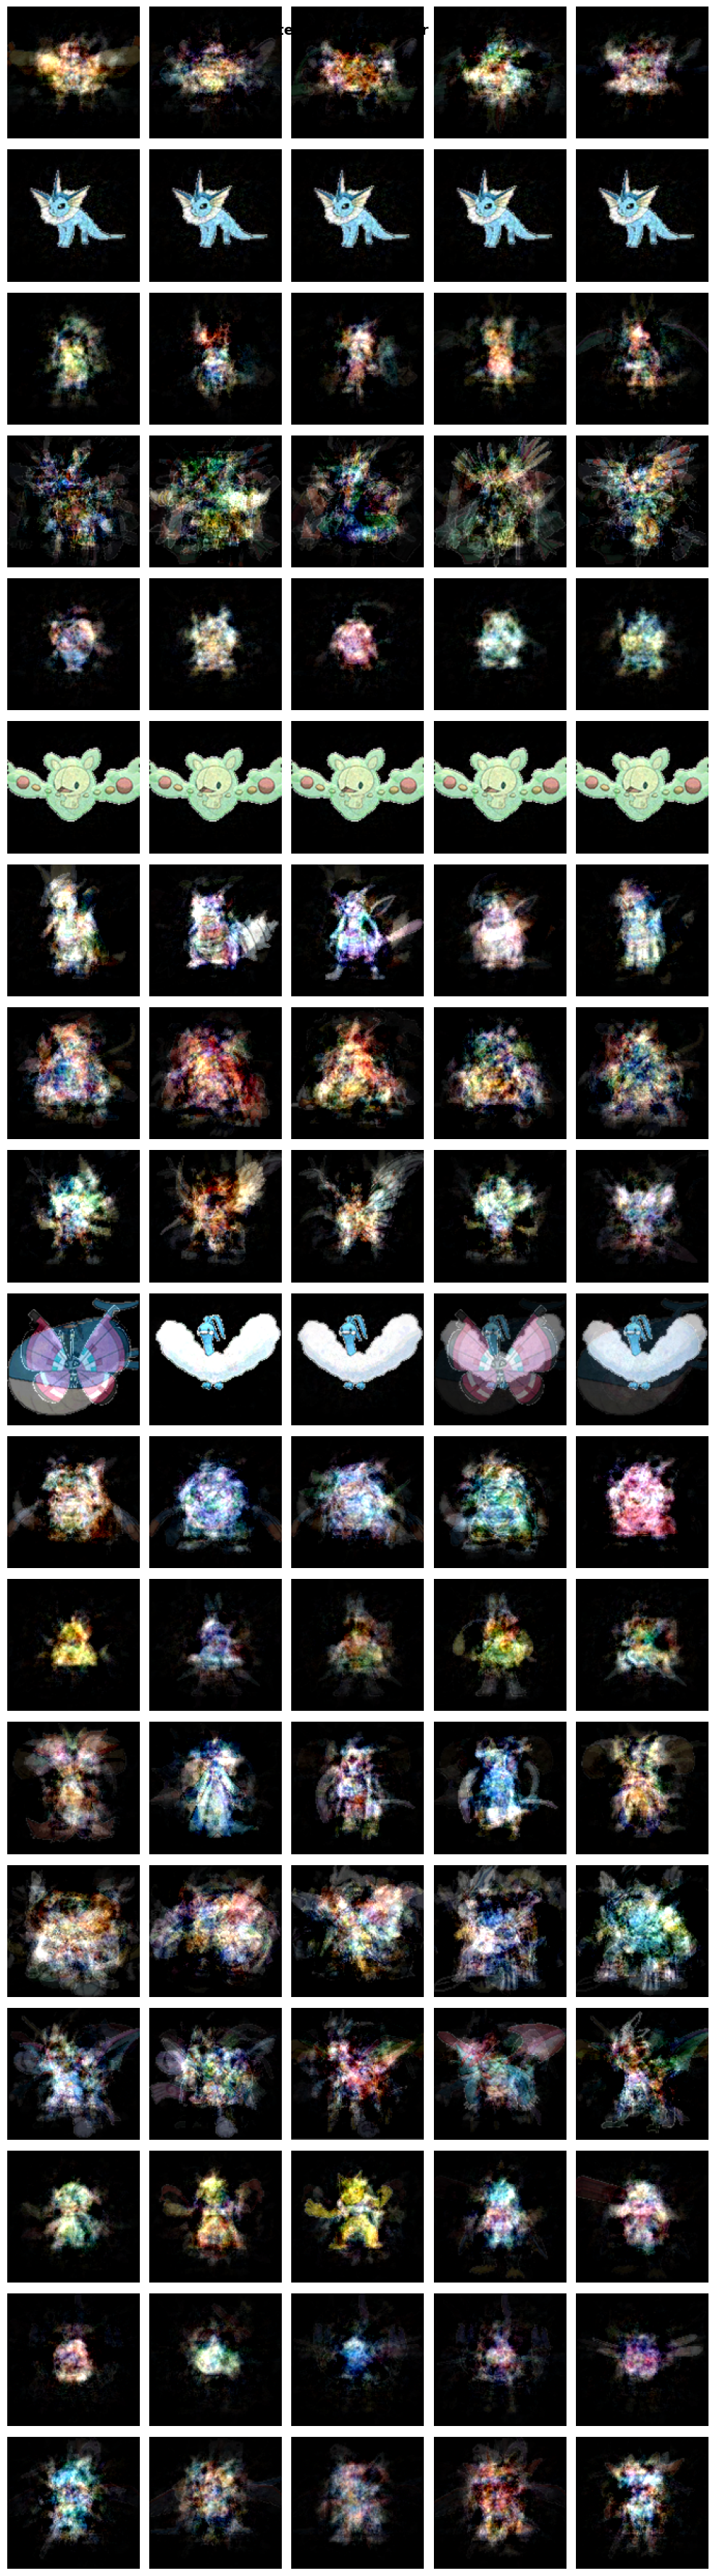

Generated 90 images total


In [ ]:
# Step 1: Get images and flatten them
images = pokemon_df["Images"].to_numpy()
images_flat = np.stack([img.flatten() for img in images])

# Step 2: Apply PCA keeping 95% variance
print("Applying PCA...")
pca = PCA(n_components=0.95)
pca_features = pca.fit_transform(images_flat)
print(f"Original dimensions: {images_flat.shape[1]}")
print(f"Reduced dimensions: {pca_features.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

# Step 4: Fit Gaussian Mixture Model
print(f"\nFitting Gaussian Mixture Model with k={unique_types}...")
gmm = GaussianMixture(n_components=unique_types, random_state=SEED, n_init=10)
gmm.fit(pca_features)

# Step 5: Generate and visualize samples
generated_images = generate_and_visualize_samples(gmm, pca, n_samples_per_cluster=5, image_size=(128, 128))
print(f"Generated {len(generated_images)} images total")

## 5D
Repeat step B, but instead of features derived using PCA, use features obtained with a pretrained ResNet model. [3 points]

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

def apply_pca_to_resnet(resnet_features, n_components=0.95):
    """
    Apply PCA to ResNet features, keeping 95% of variance.

    Parameters:
    -----------
    resnet_features : np.array
        ResNet features from penultimate layer
    n_components : float
        Fraction of variance to retain (0.95 = 95%)

    Returns:
    --------
    pca_features : np.array
        PCA-transformed features
    pca : PCA object
        Fitted PCA model
    """
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(resnet_features)

    print(f"Original dimensions: {resnet_features.shape[1]}")
    print(f"Reduced dimensions: {pca_features.shape[1]}")
    print(f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")

    return pca_features, pca

def find_optimal_clusters_bic(features, max_clusters=30, random_state=SEED):
    """
    Find optimal number of clusters using BIC (Bayesian Information Criterion).
    Lower BIC indicates better model fit with appropriate penalty for complexity.

    Parameters:
    -----------
    features : np.array
        Feature vectors
    max_clusters : int
        Maximum number of clusters to test
    random_state : int
        Random seed for reproducibility

    Returns:
    --------
    optimal_k : int
        Optimal number of clusters
    bic_scores : list
        BIC scores for each k
    """
    bic_scores = []
    k_range = range(2, max_clusters + 1)

    print("Computing BIC scores...")
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=random_state, n_init=10)
        gmm.fit(features)
        bic = gmm.bic(features)
        bic_scores.append(bic)

        if k % 5 == 0:
            print(f"  k={k}: BIC={bic:.2f}")

    # Find k with minimum BIC
    optimal_k = k_range[np.argmin(bic_scores)]

    # Plot BIC scores
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, bic_scores, 'bo-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k, color='r', linestyle='--',
                label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('BIC Score', fontsize=12)
    plt.title('BIC Score vs Number of Clusters (Lower is Better)',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal number of clusters: {optimal_k}")

    return optimal_k, bic_scores

def find_optimal_clusters_aic(features, max_clusters=30, random_state=SEED):
    """
    Find optimal number of clusters using AIC (Akaike Information Criterion).
    Alternative to BIC, generally less conservative (may select more clusters).
    """
    aic_scores = []
    k_range = range(2, max_clusters + 1)

    print("Computing AIC scores...")
    for k in k_range:
        gmm = GaussianMixture(n_components=k, random_state=random_state, n_init=10)
        gmm.fit(features)
        aic = gmm.aic(features)
        aic_scores.append(aic)

        if k % 5 == 0:
            print(f"  k={k}: AIC={aic:.2f}")

    optimal_k = k_range[np.argmin(aic_scores)]

    # Plot AIC scores
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, aic_scores, 'go-', linewidth=2, markersize=8)
    plt.axvline(x=optimal_k, color='r', linestyle='--',
                label=f'Optimal k={optimal_k}')
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('AIC Score', fontsize=12)
    plt.title('AIC Score vs Number of Clusters (Lower is Better)',
              fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nOptimal number of clusters: {optimal_k}")

    return optimal_k, aic_scores

  Processed 16/809 images...
  Processed 176/809 images...
  Processed 336/809 images...
  Processed 496/809 images...
  Processed 656/809 images...
  Processed 809/809 images...
Original dimensions: 512
Reduced dimensions: 18
Explained variance: 0.4988

Clustering Accuracy: 15.57%


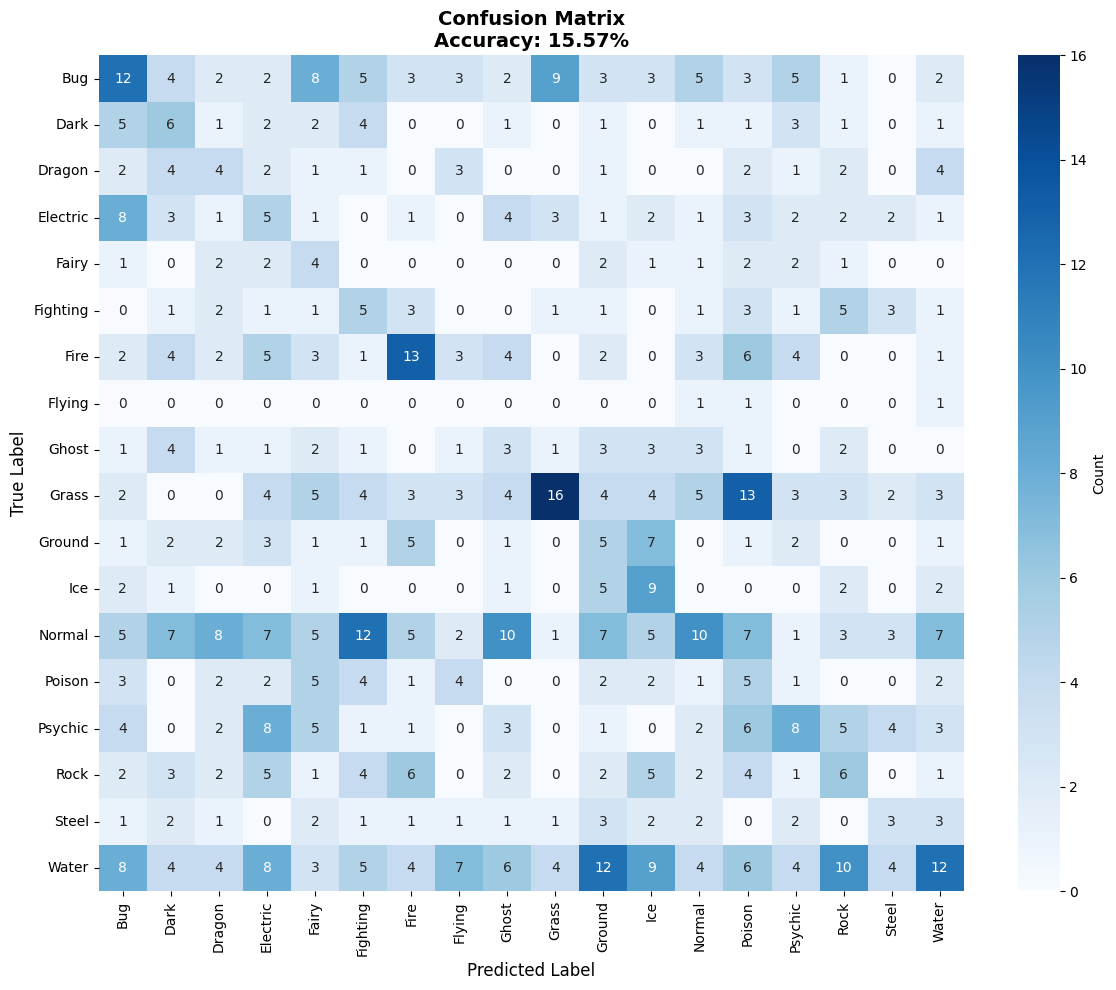

In [ ]:
# Step 1: Get ResNet features
resnet_feats = extract_resnet_features_from_df("Images_224", batch_size=16)

# Step 2: Apply PCA keeping 95% variance
pca_features, pca_model = apply_pca_to_resnet(resnet_feats, n_components=unique_types)

test_gmm(unique_types, pca_features)

# References

https://www.geeksforgeeks.org/machine-learning/implementing-pca-in-python-with-scikit-learn/

# Errata

I am leaving this here as a reminder to myself to try implementing regex matching in Python myself.

In [ ]:
# from enum import Enum
# import re

# class Category(Enum):
#   Airplane = "Airplane"
#   Car = "Car"
#   Chair = "Chair"
#   Cup = "Cup"
#   Dog = "Dog"
#   Donkey = "Donkey"
#   Duck = "Duck"
#   Hat = "Hat"

# def categorize_images(directory):
#   categories = []
#   for filename in os.listdir(path):
#     match filename:
#       case r"^Airplane": categories.append(Category.Airplane)
#       case r"^Car": categories.append(Category.Car)
#       case r"^Chair": categories.append(Category.Chair)
#       case r"^Cup": categories.append(Category.Cup)
#       case r"^Dog": categories.append(Category.Dog)
#       case r"^Donkey": categories.append(Category.Donkey)
#       case r"^Duck": categories.append(Category.Duck)
#       case r"^Hat": categories.append(Category.Hat)
#   return categories